# __Reto 9: Informe fundamentado en la visualizacion de datos__

## Objetivo

Realiza un informe donde se evalue la visualizacionb con cada uno de los connceptos aprendidos.

## Tarea 1

Vamos a trabajar con el dataset "House Prediction Rent"

In [2]:
# librerias
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración visual
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10,6)

In [3]:
df = pd.read_csv('./House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## Tarea 2

Procesar los datos

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [5]:
# mostrar valores nulos, si los hay
df.isnull().sum()

Posted On            0
BHK                  0
Rent                 0
Size                 0
Floor                0
Area Type            0
Area Locality        0
City                 0
Furnishing Status    0
Tenant Preferred     0
Bathroom             0
Point of Contact     0
dtype: int64

In [6]:
# mostrar duplicados, si los hay
df.duplicated().sum()

np.int64(0)

In [7]:
# Convertir fecha
df['Posted On'] = pd.to_datetime(df['Posted On'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          4746 non-null   datetime64[ns]
 1   BHK                4746 non-null   int64         
 2   Rent               4746 non-null   int64         
 3   Size               4746 non-null   int64         
 4   Floor              4746 non-null   object        
 5   Area Type          4746 non-null   object        
 6   Area Locality      4746 non-null   object        
 7   City               4746 non-null   object        
 8   Furnishing Status  4746 non-null   object        
 9   Tenant Preferred   4746 non-null   object        
 10  Bathroom           4746 non-null   int64         
 11  Point of Contact   4746 non-null   object        
dtypes: datetime64[ns](1), int64(4), object(7)
memory usage: 445.1+ KB


In [8]:
df.Floor.unique()

array(['Ground out of 2', '1 out of 3', '1 out of 2', 'Ground out of 1',
       'Ground out of 4', '1 out of 4', '1 out of 1', 'Ground out of 3',
       '2 out of 3', '4 out of 5', '2 out of 2', '2 out of 5',
       '4 out of 14', '3 out of 3', '5 out of 5', '4 out of 4',
       '7 out of 8', '2 out of 4', '3 out of 4', '1 out of 5',
       '8 out of 5', 'Ground out of 6', '2 out of 1',
       'Upper Basement out of 4', 'Ground out of 5', '3 out of 5',
       '11 out of 19', '5 out of 10', '11 out of 14',
       'Lower Basement out of 2', '2 out of 7', '4 out of 10',
       '7 out of 10', '2 out of 13', '6 out of 7', '4 out of 7',
       '14 out of 14', '43 out of 78', '2 out of 8', '13 out of 18',
       '5 out of 12', '18 out of 24', '3 out of 7', '17 out of 31',
       '11 out of 21', '7 out of 19', '14 out of 23', '9 out of 20',
       'Upper Basement out of 9', '19 out of 24', '3 out of 21',
       '1 out of 22', '8 out of 8', '6 out of 12', '4 out of 58',
       'Upper Basement o

In [9]:
# reemplazar valores de Floor que contienen 'Ground' por cero
df['Floor'] = df['Floor'].str.replace('Ground', '0')
df.Floor.unique() 

array(['0 out of 2', '1 out of 3', '1 out of 2', '0 out of 1',
       '0 out of 4', '1 out of 4', '1 out of 1', '0 out of 3',
       '2 out of 3', '4 out of 5', '2 out of 2', '2 out of 5',
       '4 out of 14', '3 out of 3', '5 out of 5', '4 out of 4',
       '7 out of 8', '2 out of 4', '3 out of 4', '1 out of 5',
       '8 out of 5', '0 out of 6', '2 out of 1',
       'Upper Basement out of 4', '0 out of 5', '3 out of 5',
       '11 out of 19', '5 out of 10', '11 out of 14',
       'Lower Basement out of 2', '2 out of 7', '4 out of 10',
       '7 out of 10', '2 out of 13', '6 out of 7', '4 out of 7',
       '14 out of 14', '43 out of 78', '2 out of 8', '13 out of 18',
       '5 out of 12', '18 out of 24', '3 out of 7', '17 out of 31',
       '11 out of 21', '7 out of 19', '14 out of 23', '9 out of 20',
       'Upper Basement out of 9', '19 out of 24', '3 out of 21',
       '1 out of 22', '8 out of 8', '6 out of 12', '4 out of 58',
       'Upper Basement out of 16', '60 out of 66', '34

In [10]:
# separar Floor en dos columnas: Current Floor y Total Floor
df[['Current_Floor', 'Total_Floors']] = (
    df['Floor'].str.extract(r'(\d+)\s*out of\s*(\d+)')
)

df.sample(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Current_Floor,Total_Floors
2554,2022-06-11,3,10000,100,1 out of 4,Carpet Area,Krishna Nagar,Delhi,Furnished,Bachelors/Family,2,Contact Owner,1,4
424,2022-05-31,2,12000,800,1 out of 2,Super Area,Dum Dum,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,1,2
1351,2022-07-07,1,20000,465,3 out of 4,Super Area,in Borivali East,Mumbai,Semi-Furnished,Bachelors,1,Contact Owner,3,4
3812,2022-07-06,2,8500,650,1 out of 2,Super Area,Jalladian Pet,Chennai,Semi-Furnished,Bachelors/Family,2,Contact Owner,1,2
4744,2022-07-06,3,45000,1500,23 out of 34,Carpet Area,Gachibowli,Hyderabad,Semi-Furnished,Family,2,Contact Agent,23,34


In [11]:
# convertir valores de current y total Floor a numerico
df['Current_Floor'] = pd.to_numeric(df['Current_Floor'])
df['Total_Floors'] = pd.to_numeric(df['Total_Floors'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Posted On          4746 non-null   datetime64[ns]
 1   BHK                4746 non-null   int64         
 2   Rent               4746 non-null   int64         
 3   Size               4746 non-null   int64         
 4   Floor              4746 non-null   object        
 5   Area Type          4746 non-null   object        
 6   Area Locality      4746 non-null   object        
 7   City               4746 non-null   object        
 8   Furnishing Status  4746 non-null   object        
 9   Tenant Preferred   4746 non-null   object        
 10  Bathroom           4746 non-null   int64         
 11  Point of Contact   4746 non-null   object        
 12  Current_Floor      4708 non-null   float64       
 13  Total_Floors       4708 non-null   float64       
dtypes: datet

In [12]:
# detectar registros inconsistentes
floors_invalid = df[df['Current_Floor'] > df['Total_Floors']]
floors_invalid

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Current_Floor,Total_Floors
105,2022-06-06,1,6000,600,8 out of 5,Carpet Area,Pratiraksha Nagar,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner,8.0,5.0
161,2022-06-27,2,10000,450,2 out of 1,Carpet Area,Behala,Kolkata,Semi-Furnished,Bachelors/Family,2,Contact Owner,2.0,1.0


In [13]:
# eliminar registros inconsistentes
df = df[df['Current_Floor'] <= df['Total_Floors']]

floors_invalid = df[df['Current_Floor'] > df['Total_Floors']]
floors_invalid

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Current_Floor,Total_Floors


In [14]:
df.sample(5)

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Current_Floor,Total_Floors
3649,2022-06-02,2,16000,930,1 out of 4,Super Area,Mogappair East,Chennai,Semi-Furnished,Bachelors/Family,2,Contact Owner,1.0,4.0
214,2022-06-04,2,11000,750,0 out of 1,Carpet Area,Parnasree Pally,Kolkata,Unfurnished,Bachelors,1,Contact Owner,0.0,1.0
3500,2022-04-30,2,8500,450,1 out of 2,Carpet Area,"Suriyammapet, Saidapet",Chennai,Unfurnished,Bachelors/Family,1,Contact Owner,1.0,2.0
1080,2022-07-06,3,98000,1233,35 out of 68,Carpet Area,"Auris Serenity, Kanch Pada",Mumbai,Semi-Furnished,Bachelors/Family,4,Contact Agent,35.0,68.0
1435,2022-06-14,3,85000,890,4 out of 27,Carpet Area,"Oberoi Splendor, JVLR-Jogeshwari Vikhroli Link...",Mumbai,Furnished,Bachelors/Family,2,Contact Agent,4.0,27.0


## Tarea 3

Aplicar EDA sobre los datos

__Estadistica descriptiva de variables numericas__

In [15]:
# estadistica descriptiva de variables numericas
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Posted On,4706,2022-06-07 18:10:15.044623872,2022-04-13 00:00:00,2022-05-20 00:00:00,2022-06-10 00:00:00,2022-06-28 00:00:00,2022-07-11 00:00:00,NaN
BHK,4706.0,2.083723,1.0,2.0,2.0,3.0,6.0,0.832013
Rent,4706.0,34838.912027,1200.0,10000.0,16000.0,32800.0,3500000.0,78027.274315
Size,4706.0,966.50085,10.0,550.0,850.0,1200.0,8000.0,628.355027
Bathroom,4706.0,1.965151,1.0,1.0,2.0,2.0,10.0,0.883463
Current_Floor,4706.0,3.471738,0.0,1.0,2.0,3.0,76.0,5.783202
Total_Floors,4706.0,6.955801,1.0,2.0,4.0,6.0,89.0,9.465782


__Tratamiento de Outliers__

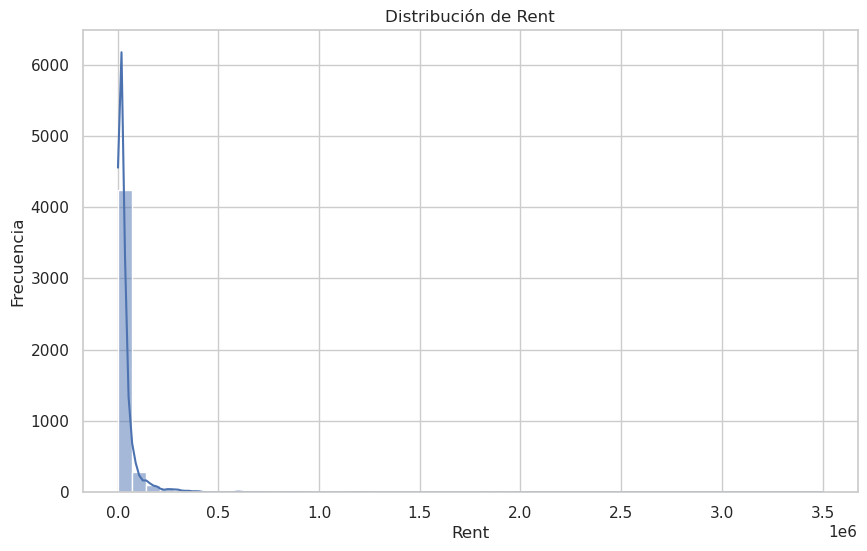

In [16]:
# Distribucion de Rent
fig, ax = plt.subplots()

sns.histplot(data=df,x='Rent',bins=50,kde=True,ax=ax)
ax.set_title('Distribución de Rent')
ax.set_xlabel('Rent')
ax.set_ylabel('Frecuencia')
plt.show()

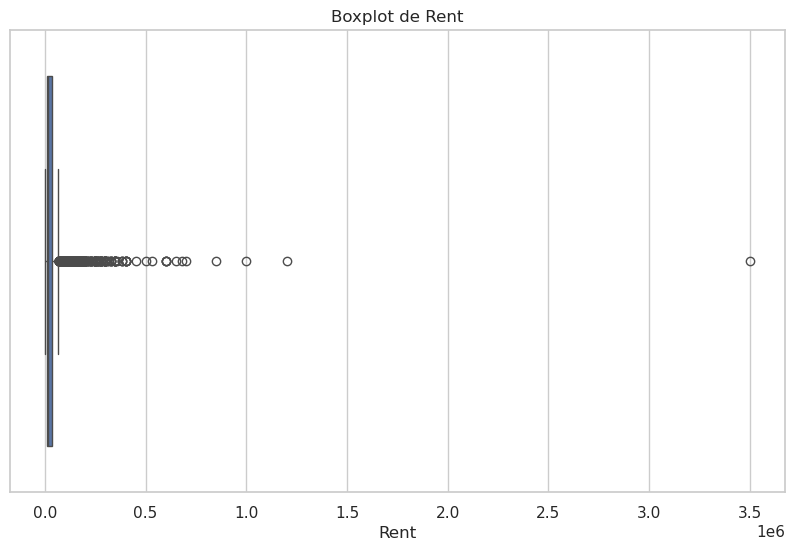

In [17]:
# boxplot de Rent
fig, ax = plt.subplots()

sns.boxplot(data=df,x='Rent',ax=ax)
ax.set_title('Boxplot de Rent')
plt.show()

In [19]:
# eliminar el 1% de los registros con Rent mas extremos
upper = df['Rent'].quantile(0.99)
df_clean = df[df['Rent'] <= upper]
df_clean.shape

(4667, 14)

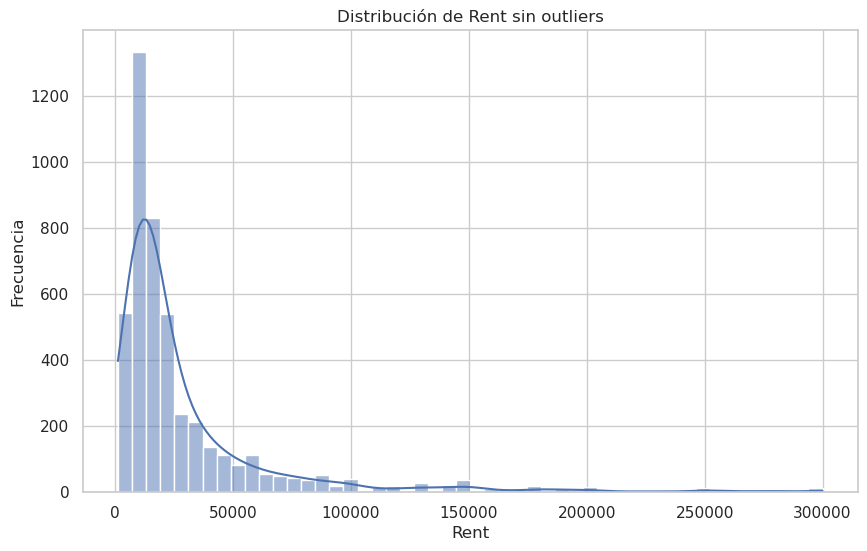

In [20]:
# Distribucion de Rent con outliers excluidos
fig, ax = plt.subplots()

sns.histplot(data=df_clean,x='Rent',bins=50,kde=True,ax=ax)
ax.set_title('Distribución de Rent sin outliers')
ax.set_xlabel('Rent')
ax.set_ylabel('Frecuencia')
plt.show()

__Relacion entre variables numericas y Rent__

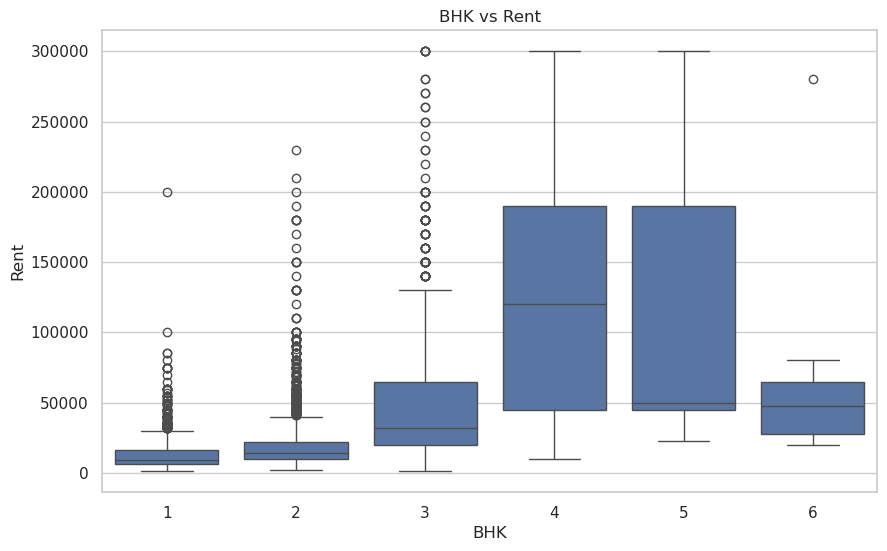

In [21]:
# BHK vs Rent
fig, ax = plt.subplots()

sns.boxplot(data=df_clean, x='BHK', y='Rent', ax=ax)
ax.set_title('BHK vs Rent')
plt.show()

> A mayor numero de habitaciones, mayor es el valor del arriendo.

> La mediana del arriendo aumenta con el numero de habitaciones. El grupo de 6 habitaciones parece tener un comportamiento irregular.

> La variabiidad del recio aumenta en viviendas grandes. Para inmuebles con 4 y 5 habitaciones los precios varian ampliamente. Es decir, hay inmuebles economicos y otros extremadamente costosos dentro del mismo grupo

> Hay una gran cantidad de outliers en los inmuebles con 1, 2 y 3 habitaciones. 

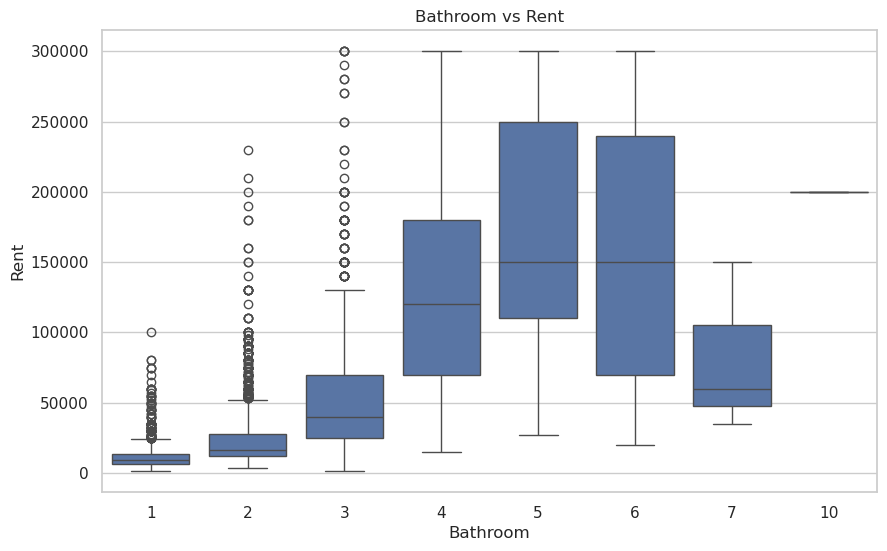

In [22]:
# Bathroom vs Rent
fig, ax = plt.subplots()

sns.boxplot(data=df_clean, x='Bathroom', y='Rent', ax=ax)
ax.set_title('Bathroom vs Rent')
plt.show()

> Propiedades con mas baños tienen arriendos mas altos.

> La mediana del precio aumeta progresivamente desde 1 hasta 6 baños.

> La variabilidad del precio aumenta con mas baños.

> Hay presencia de outliers para inmuebles co 1, 2 y 3 baños. Puede corresponder a propiedades en zonas exclusivas.

> Verifiquemos la cantidad de inmuebles con 10 baños. Si son muy pocos, lo eliminamos ya que no aporta valor.


In [23]:
df_clean['Bathroom'].value_counts()  

Bathroom
2     2270
1     1462
3      739
4      140
5       41
6       11
7        3
10       1
Name: count, dtype: int64

> Propiedades con 1, 2 y 3 baños son los que contienen la mayoria de los datos. Se evidencia que pertenecen a propiedades de bajo arriendo.

> Propiedades con mas de 3 baños son muy pocas, pero son las mas costosas.

> Agrupamos los inmuebles en categorias, creando una que almacene aquellos con mas de 4 baños.

In [25]:
df_clean['Bathroom_grouped'] = df_clean['Bathroom'].apply(
    lambda x: '5+' if x > 4 else str(x)
)
df_clean.sample(5)

/tmp/ipykernel_1343/1252307378.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Bathroom_grouped'] = df_clean['Bathroom'].apply(


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact,Current_Floor,Total_Floors,Bathroom_grouped
3294,2022-05-15,1,8000,700,1 out of 2,Super Area,Velachery,Chennai,Unfurnished,Bachelors/Family,2,Contact Owner,1.0,2.0,2
4316,2022-07-06,2,36000,1100,1 out of 5,Super Area,Madhapur,Hyderabad,Furnished,Bachelors/Family,2,Contact Owner,1.0,5.0,2
1928,2022-04-28,1,6000,600,3 out of 3,Super Area,Hongasandra,Bangalore,Unfurnished,Bachelors/Family,1,Contact Owner,3.0,3.0,1
2210,2022-05-19,2,21000,1100,3 out of 4,Carpet Area,Hennur Main Road,Bangalore,Furnished,Bachelors,2,Contact Agent,3.0,4.0,2
3917,2022-06-17,2,9000,1000,1 out of 2,Super Area,Hydershakote,Hyderabad,Unfurnished,Bachelors,2,Contact Owner,1.0,2.0,2
